In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup successful!")

Setup successful!


In [9]:
df = pd.read_excel("C:\E-Commerce-DataAnalysis\data\Online_Retail.xlsx")

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.shape

(541909, 8)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [15]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [16]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

In [18]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [19]:
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [20]:
df['UnitPrice'].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [21]:
df[df['UnitPrice']<=0].shape

(2517, 9)

In [22]:
df[df['UnitPrice'] <= 0][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Country']
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


In [23]:
df[df['UnitPrice'] < 0].shape

(2, 9)

In [24]:
df[df['UnitPrice'] == 0].shape

(2515, 9)

In [25]:
(df[df['UnitPrice'] <= 0].shape[0] / df.shape[0]) * 100

0.46446912673530055

In [26]:
clean_df = df[df['UnitPrice'] > 0].copy()

In [27]:
clean_df.shape

(539392, 9)

In [28]:
clean_df[clean_df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 9)

In [29]:
clean_df['Description'].isnull().sum()


np.int64(0)

In [30]:
clean_df['CustomerID'].isnull().sum()

np.int64(132603)

In [31]:
clean_df['CustomerID'].isnull().sum() / clean_df.shape[0] * 100

np.float64(24.58379063834836)

In [32]:
customer_df = clean_df.dropna(subset=['CustomerID']).copy()

In [33]:
customer_df.shape

(406789, 9)

In [34]:
customer_df.duplicated().sum()

np.int64(5225)

In [35]:
customer_df[customer_df.duplicated(keep=False)].sort_values(
    by=['InvoiceNo', 'StockCode']
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,3.30
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65


In [36]:
final_df = customer_df.drop_duplicates().copy()

In [37]:
final_df.shape

(401564, 9)

In [38]:
final_df.duplicated().sum()

np.int64(0)

In [39]:
final_df['Quantity'].describe()

count    401564.000000
mean         12.149911
std         249.512649
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [40]:
final_df.nlargest(10, 'Quantity')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Revenue']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609.0,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,16308.0,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,16754.0,518.40


In [41]:
final_df.nsmallest(10, 'Quantity')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Revenue']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Revenue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0,-168469.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0,-77183.60
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03,15838.0,-280.80
160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2.10,15749.0,-6539.40
160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,1.85,15749.0,-3700.00
160143,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2.55,15749.0,-4921.50
224419,C556522,22920,HERB MARKER BASIL,-1515,0.55,16938.0,-833.25
187609,C552995,M,Manual,-1350,0.16,18133.0,-216.00
160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2.55,15749.0,-3315.00
390544,C570556,20971,PINK BLUE FELT CRAFT TRINKET BOX,-1296,1.06,16029.0,-1373.76


In [42]:
clean_df['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [43]:
clean_df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [44]:
clean_df['Revenue'].sum()

np.float64(9769872.054)

## 1. Total Net Revenue

### Business Question
What is the total net revenue generated from all valid transactions?

### Approach
Since the `Revenue` column represents the revenue for each transaction, we sum the entire column to calculate total net revenue.

### Result
The total net revenue generated is approximately £9.77 million.

In [45]:
clean_df['Revenue'].sum()

np.float64(9769872.054)

## 2. Monthly Revenue Analysis

### Business Question
Which month generated the highest revenue?

In [46]:
clean_df['InvoiceDate'].dt.to_period('M')

0         2010-12
1         2010-12
2         2010-12
3         2010-12
4         2010-12
           ...   
541904    2011-12
541905    2011-12
541906    2011-12
541907    2011-12
541908    2011-12
Name: InvoiceDate, Length: 539392, dtype: period[M]

In [47]:
clean_df.groupby(clean_df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

InvoiceDate
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     704804.630
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64

Business Insight: November 2011 generated the highest revenue, at approximately £1.46 million. December 2011 should not be directly compared with other months because the dataset only contains transactions through December 9, 2011.

## 3. Monthly Transaction Analysis

### Business Question
Which month had the highest number of transactions?

### Approach
Count the number of unique invoices for each month-year to determine the monthly transaction volume.

In [48]:
clean_df.groupby(
    clean_df['InvoiceDate'].dt.to_period('M')
)['InvoiceNo'].nunique()

InvoiceDate
2010-12    1885
2011-01    1346
2011-02    1319
2011-03    1772
2011-04    1486
2011-05    1995
2011-06    1862
2011-07    1745
2011-08    1639
2011-09    2170
2011-10    2402
2011-11    3210
2011-12     965
Freq: M, Name: InvoiceNo, dtype: int64

### Business Insight
November 2011 had the highest transaction volume, with 3,210 unique invoices. This aligns with November also being the highest-revenue month.

In [50]:
clean_df.groupby('StockCode')['Revenue'].sum().sort_values()

StockCode
AMAZONFEE      -221520.500
M               -68674.190
CRUK             -7933.430
BANK CHARGES     -7175.639
D                -5696.220
                   ...    
85099B           92356.030
85123A           97894.500
47566            98302.980
22423           164762.190
DOT             206245.480
Name: Revenue, Length: 3938, dtype: float64

## 4. Product-wise Revenue Analysis

### Business Question
Which products generated the highest revenue?

### Approach
Group the transactions by `StockCode`, calculate the total revenue generated by each product by summing the `Revenue` column, and sort the results in descending order to identify the highest-revenue products.

In [53]:
clean_df.groupby(['StockCode'])['Revenue'].sum().sort_values(ascending=False)

StockCode
DOT             206245.480
22423           164762.190
47566            98302.980
85123A           97894.500
85099B           92356.030
                   ...    
D                -5696.220
BANK CHARGES     -7175.639
CRUK             -7933.430
M               -68674.190
AMAZONFEE      -221520.500
Name: Revenue, Length: 3938, dtype: float64

### Business Insight
The product with the highest recorded revenue is `DOT`, generating approximately £206,245.48, followed by `22423` with approximately £164,762.19.

## 5. Top Revenue-Generating Products

### Business Question
What are the top 5 products based on total revenue?

### Approach
Group the transactions by both `StockCode` and `Description`, calculate the total revenue for each product, sort the results in descending order, and identify the top 5 products.

In [54]:
clean_df.groupby(['StockCode','Description'])['Revenue'].sum().sort_values(ascending=False)

StockCode     Description                       
DOT           DOTCOM POSTAGE                        206245.480
22423         REGENCY CAKESTAND 3 TIER              164762.190
47566         PARTY BUNTING                          98302.980
85123A        WHITE HANGING HEART T-LIGHT HOLDER     97715.990
85099B        JUMBO BAG RED RETROSPOT                92356.030
                                                       ...    
D             Discount                               -5696.220
BANK CHARGES  Bank Charges                           -7175.639
CRUK          CRUK Commission                        -7933.430
M             Manual                                -68674.190
AMAZONFEE     AMAZON FEE                           -221520.500
Name: Revenue, Length: 4177, dtype: float64

### Business Insight
`DOT` (DOTCOM POSTAGE) has the highest recorded revenue, followed by `REGENCY CAKESTAND 3 TIER` and `PARTY BUNTING`. However, some StockCodes represent non-product transactions such as postage, discounts, bank charges, and fees. These should be considered separately when identifying the highest-revenue products.

## 6. Top Revenue-Generating Products (Actual Products Only)

### Business Question
Which actual products generated the highest revenue?

### Approach
Exclude non-product transactions such as postage, discounts, bank charges, commissions, fees, and manual adjustments. Then group the remaining transactions by `StockCode` and `Description`, calculate total revenue, and sort the results in descending order.

In [55]:
non_product_codes = ['DOT','D','BANK CHARGES','CRUK','AMAZONFEE','M']

In [56]:
clean_df[~clean_df['StockCode'].isin(non_product_codes)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [57]:
product_df = clean_df[~clean_df['StockCode'].isin(non_product_codes)]

In [58]:
product_df['StockCode'].unique()

array(['85123A', 71053, '84406B', ..., '90214U', '47591b', 23843],
      shape=(3932,), dtype=object)

In [59]:
product_df.groupby(['StockCode','Description'])['Revenue'].sum().sort_values(ascending=False)

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              164762.19
47566      PARTY BUNTING                          98302.98
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97715.99
85099B     JUMBO BAG RED RETROSPOT                92356.03
23084      RABBIT NIGHT LIGHT                     66756.59
                                                   ...    
21645      ASSORTED TUTTI FRUTTI ROUND BOX          -39.60
35400      WOODEN BOX ADVENT CALENDAR               -45.70
85063      CREAM SWEETHEART MAGAZINE RACK           -46.85
79323W     WHITE CHERRY LIGHTS                      -54.00
S          SAMPLES                                -3049.39
Name: Revenue, Length: 4171, dtype: float64

### Business Insight
After excluding non-product transactions, `REGENCY CAKESTAND 3 TIER` generated the highest revenue at approximately £164,762, followed by `PARTY BUNTING` and `WHITE HANGING HEART T-LIGHT HOLDER`.

## 7. Top-Selling Products by Quantity

### Business Question
Which products had the highest total quantity sold?

### Approach
Group the actual product transactions by `StockCode` and `Description`, sum the `Quantity` for each product, and sort the results in descending order to identify the products with the highest sales volume.

In [60]:
product_df.groupby(['StockCode','Description'])['Quantity'].sum().sort_values(ascending=False)

StockCode  Description                      
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS    53847
85099B     JUMBO BAG RED RETROSPOT              47359
84879      ASSORTED COLOUR BIRD ORNAMENT        36381
22197      POPCORN HOLDER                       36334
21212      PACK OF 72 RETROSPOT CAKE CASES      36039
                                                ...  
20703      BLUE PADDED SOFT MOBILE                 -6
21144      PINK POODLE HANGING DECORATION          -7
79323W     WHITE CHERRY LIGHTS                     -8
21645      ASSORTED TUTTI FRUTTI ROUND BOX        -24
S          SAMPLES                                -59
Name: Quantity, Length: 4171, dtype: int64

### Business Insight
`WORLD WAR 2 GLIDERS ASSTD DESIGNS` had the highest sales volume with 53,847 units sold, followed by `JUMBO BAG RED RETROSPOT` with 47,359 units. `JUMBO BAG RED RETROSPOT` also ranks among the top products by revenue, indicating both high sales volume and strong revenue contribution.

## 8. Top Customers by Revenue

### Business Question
Which customers generated the highest revenue?

### Approach
Group the transactions by `CustomerID`, calculate the total revenue generated by each customer by summing the `Revenue` column, and sort the results in descending order to identify the highest-value customers.

In [61]:
customer_df = product_df.dropna(subset = ['CustomerID'])

In [62]:
customer_df.groupby(['CustomerID'])['Revenue'].sum().sort_values(ascending=False)

CustomerID
14646.0    279801.02
18102.0    259657.30
17450.0    188797.13
14911.0    133007.13
12415.0    123725.45
             ...    
12666.0      -227.44
16252.0      -295.09
16742.0      -464.90
15823.0      -811.86
14213.0     -1192.20
Name: Revenue, Length: 4362, dtype: float64

### Business Insight
Customer `14646` generated the highest net revenue at approximately £279,801, followed by customers `18102` and `17450`. This indicates that a relatively small number of customers may contribute significantly to overall revenue.

## 9. Revenue by Country

### Business Question
Which countries generated the highest revenue?

### Approach
Group the transactions by `Country`, calculate the total revenue generated by each country by summing the `Revenue` column, and sort the results in descending order to identify the highest-revenue countries.

In [63]:
product_df.groupby(['Country'])['Revenue'].sum().sort_values(ascending=False)

Country
United Kingdom          8310485.743
Netherlands              284973.540
EIRE                     264838.460
Germany                  221629.400
France                   197414.390
Australia                137077.270
Spain                     57617.200
Switzerland               56385.350
Belgium                   40910.960
Sweden                    36565.910
Japan                     35419.790
Norway                    35163.460
Portugal                  29379.520
Finland                   21775.540
Channel Islands           20086.290
Denmark                   18768.140
Italy                     16921.340
Cyprus                    12946.290
Austria                   10154.320
Hong Kong                 10117.040
Singapore                  9120.390
Israel                     7907.820
Poland                     7213.140
Unspecified                4749.790
Greece                     4710.520
Iceland                    4310.000
Canada                     3666.380
Malta               

In [64]:
country_revenue = product_df.groupby(['Country'])['Revenue'].sum().sort_values(ascending=False)

In [65]:
top_10_countries = country_revenue.head(10)

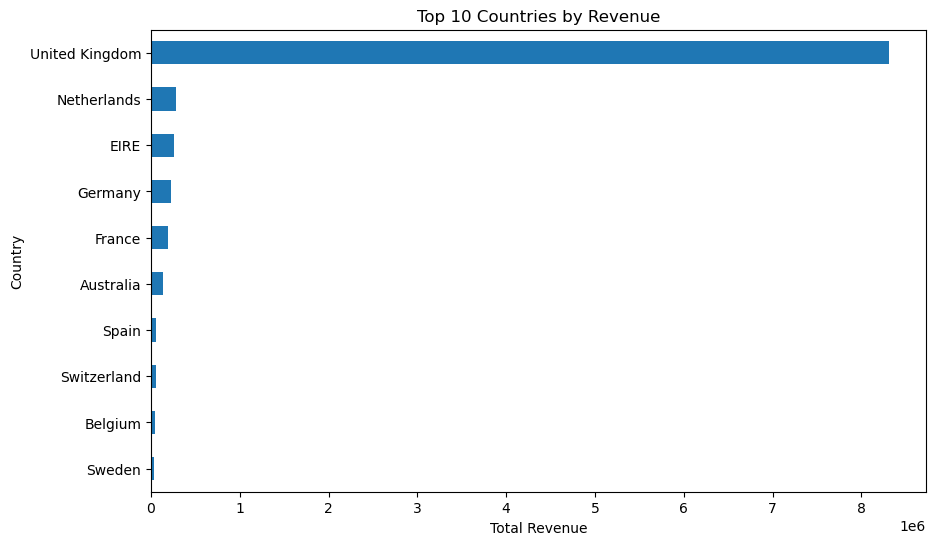

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
top_10_countries.plot(kind = 'barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.show()

### Business Insight

The United Kingdom generated significantly higher revenue than all other countries, contributing approximately £8.31 million. The Netherlands, EIRE, Germany, and France were the next highest-revenue markets. This indicates that the business is heavily dependent on the UK market, while other European countries represent smaller but important markets.

## 10. Number of Orders by Country

### Business Question
Which countries have the highest number of orders?

### Approach
Count the unique `InvoiceNo` values for each country to determine the number of orders placed. Then sort the results in descending order to identify the countries with the highest order volume.

In [67]:
country_orders = product_df.groupby(['Country'])['InvoiceNo'].nunique().sort_values(ascending=False)

In [68]:
country_orders

Country
United Kingdom          21052
Germany                   592
France                    455
EIRE                      349
Belgium                   119
Spain                     102
Netherlands                99
Switzerland                74
Australia                  69
Portugal                   58
Italy                      53
Finland                    47
Sweden                     46
Norway                     37
Channel Islands            31
Japan                      25
Poland                     24
Denmark                    21
Austria                    19
Cyprus                     18
Unspecified                13
Malta                      10
Israel                      9
Hong Kong                   9
USA                         7
Iceland                     7
Greece                      6
Canada                      6
European Community          5
Czech Republic              5
Bahrain                     4
Lithuania                   4
Singapore                   4
Un

In [69]:
top_10_country_orders = country_orders.head(10)

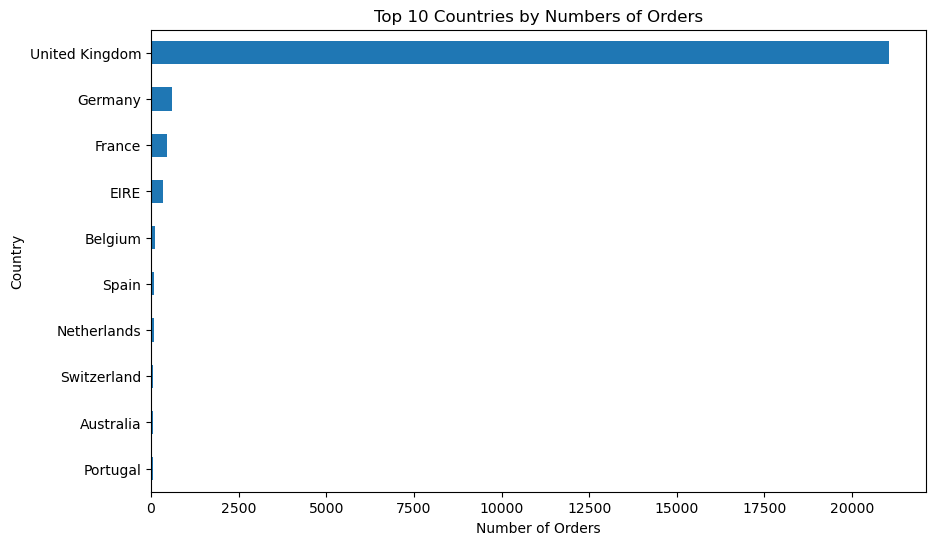

In [71]:
plt.figure(figsize=(10,6))
top_10_country_orders.plot(kind = 'barh')
plt.title('Top 10 Countries by Numbers of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.show()

### Business Insight

The United Kingdom had the highest number of orders by a large margin, with 21,052 orders, followed by Germany and France. The high order volume in the UK is consistent with its position as the largest revenue-generating market. However, differences between order counts and revenue suggest that average order value may vary considerably across countries.


## 11. Average Order Value by Country

### Business Question
Which countries have the highest average order value?

### Approach
Calculate the total revenue and number of unique orders for each country, then divide total revenue by the number of orders to obtain the average order value (AOV). Sort the results in descending order to identify countries with higher-value orders.

In [72]:
country_AOV = country_revenue/country_orders.sort_values(ascending=False)

In [73]:
country_AOV

Country
Australia               1986.627101
Austria                  534.437895
Bahrain                  137.100000
Belgium                  343.789580
Brazil                  1143.600000
Canada                   611.063333
Channel Islands          647.944839
Cyprus                   719.238333
Czech Republic           141.544000
Denmark                  893.720952
EIRE                     758.849456
European Community       258.350000
Finland                  463.309362
France                   433.877780
Germany                  374.373986
Greece                   785.086667
Hong Kong               1124.115556
Iceland                  615.714286
Israel                   878.646667
Italy                    319.270566
Japan                   1416.791600
Lebanon                 1693.880000
Lithuania                415.265000
Malta                    250.547000
Netherlands             2878.520606
Norway                   950.363784
Poland                   300.547500
Portugal            

### Business Insight

Australia recorded the highest average order value among the countries in the dataset at approximately £1,987 per order, followed by Lebanon and Japan. However, AOV can be strongly influenced by countries with a small number of orders. Therefore, country-level AOV should be interpreted alongside order volume before drawing business conclusions.

In [74]:
countries_50_plus = country_orders[country_orders >= 50]
country_AOV_50_plus = (country_revenue[countries_50_plus.index]/countries_50_plus).sort_values(ascending=False)
country_AOV_50_plus.head(10)

Country
Netherlands       2878.520606
Australia         1986.627101
Switzerland        761.964189
EIRE               758.849456
Spain              564.874510
Portugal           506.543448
France             433.877780
United Kingdom     394.759916
Germany            374.373986
Belgium            343.789580
dtype: float64

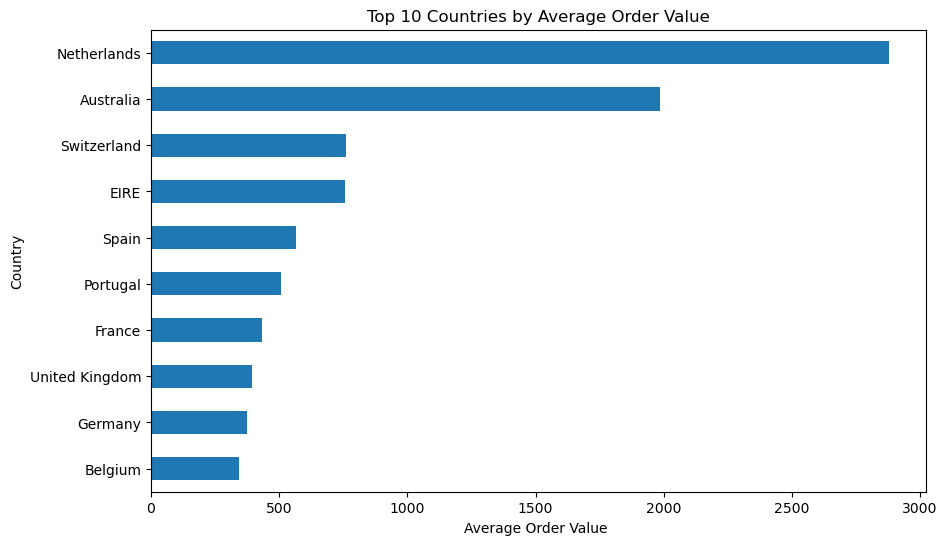

In [75]:
top_10_AOV = country_AOV_50_plus.head(10)
plt.figure(figsize=(10,6))
top_10_AOV.plot(kind = 'barh')
plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Average Order Value ')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.show()

## 12. Monthly Revenue Trend

### Business Question
How did the company's revenue change over time?

### Approach
Group the transactions by month and calculate the total revenue for each month. A line chart will then be used to visualize the revenue trend over time and identify patterns, peaks, and declines.

In [76]:
monthly_revenue = clean_df.groupby(clean_df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

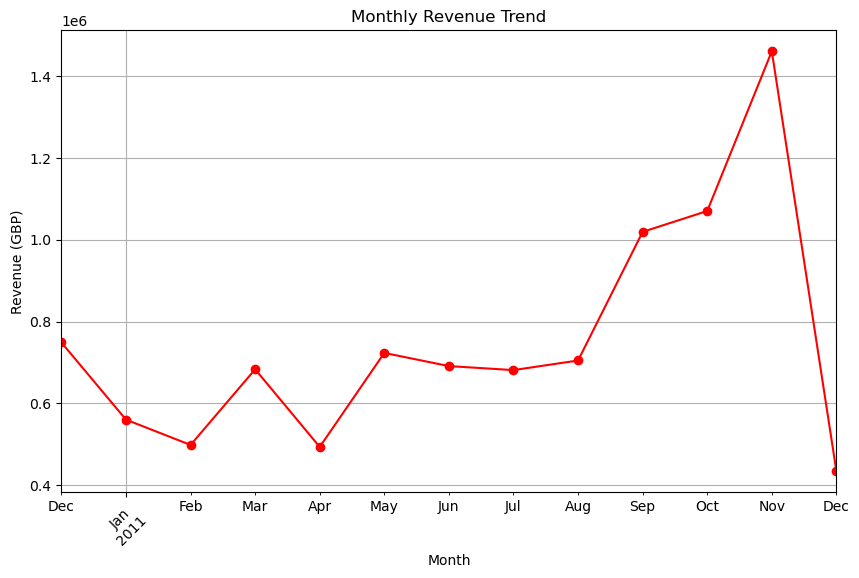

In [78]:
plt.figure(figsize=(10,6))
monthly_revenue.plot(kind = 'line',marker = 'o',color = 'red')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (GBP)')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

### Business Insight

Monthly revenue shows a fluctuating pattern throughout the period, with noticeable variations between months. Revenue reached its highest level around November 2011 before declining in December 2011. The strong performance toward the end of 2011 may indicate increased customer purchasing activity during the holiday season.

## 13. Monthly Order Volume

### Business Question
How did the number of orders change over time?

### Approach
Group the transactions by month and count the number of unique invoices to determine the monthly order volume. A line chart will be used to visualize changes in order activity over time.

In [79]:
monthly_orders = clean_df.groupby(clean_df['InvoiceDate'].dt.to_period('M'))['InvoiceNo'].nunique()

In [80]:
monthly_orders

InvoiceDate
2010-12    1885
2011-01    1346
2011-02    1319
2011-03    1772
2011-04    1486
2011-05    1995
2011-06    1862
2011-07    1745
2011-08    1639
2011-09    2170
2011-10    2402
2011-11    3210
2011-12     965
Freq: M, Name: InvoiceNo, dtype: int64

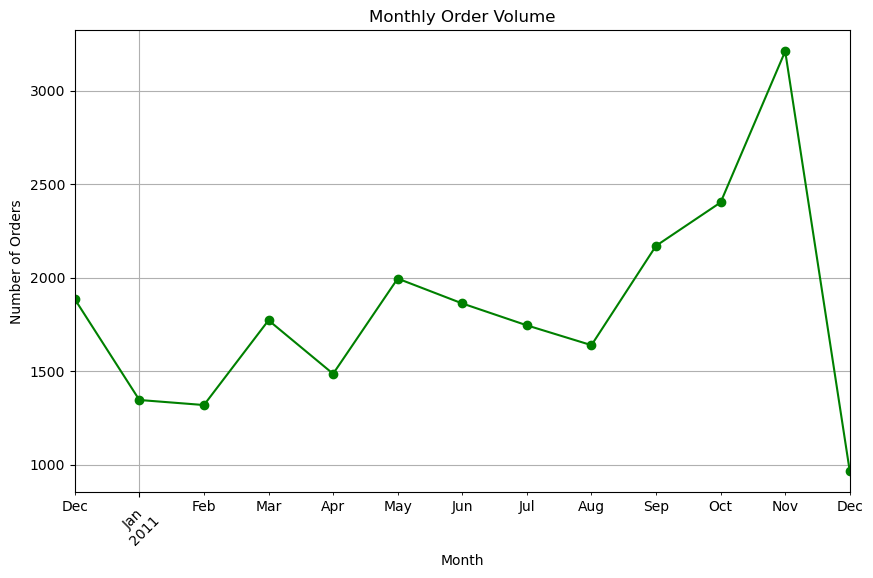

In [81]:
plt.figure(figsize=(10,6))
monthly_orders.plot(kind = 'line',marker = 'o',color = 'green')
plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Business Insight

Order volume fluctuated throughout the year, with a general increase during the later months. November 2011 recorded the highest number of orders at 3,210, while December 2011 experienced a sharp decline to 965 orders. The sharp December decline should be interpreted carefully because the dataset may not contain a complete month of December transactions.

## 14. Monthly Average Order Value

### Business Question
How did the average value of an order change over time?

### Approach
Calculate the average order value for each month by dividing monthly revenue by the number of unique orders. A line chart will be used to identify changes in customer spending per order over time.

In [82]:
monthly_aov = monthly_revenue / monthly_orders

In [83]:
monthly_aov

InvoiceDate
2010-12    397.324679
2011-01    416.047741
2011-02    377.606255
2011-03    385.590903
2011-04    331.902504
2011-05    362.573188
2011-06    371.172460
2011-07    390.429863
2011-08    430.021129
2011-09    469.902130
2011-10    445.755483
2011-11    455.375779
2011-12    449.396902
Freq: M, dtype: float64

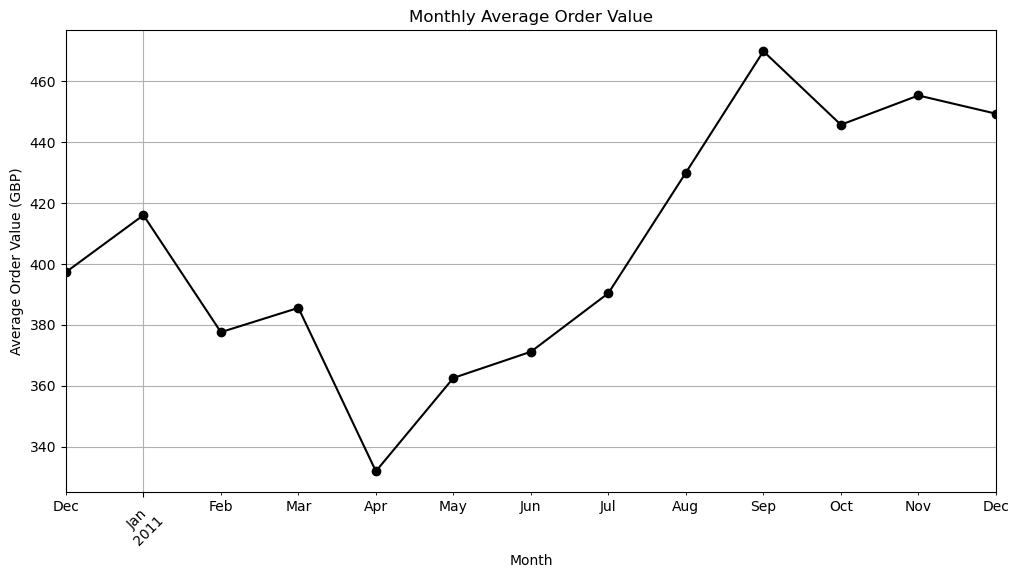

In [84]:
plt.figure(figsize=(12,6))
monthly_aov.plot(kind = 'line',marker = 'o',color = 'black')
plt.title('Monthly Average Order Value')
plt.xlabel('Month')
plt.ylabel('Average Order Value (GBP)')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

### Business Insight

The average order value fluctuated throughout the year, ranging from approximately GBP 332 to GBP 470. The highest AOV was recorded in September 2011, while April 2011 had the lowest. Although November 2011 had the highest order volume, its AOV was lower than the September peak, indicating that the increase in November revenue was driven more by higher order volume than by higher spending per order.

## 15. Top 10 Products by Revenue

### Business Question
Which products generated the highest revenue?

### Approach
Group the transactions by `StockCode` and `Description`, calculate the total revenue generated by each product, sort the results in descending order, and select the top 10 products for analysis and visualization.

In [85]:
product_revenue = product_df.groupby(
    ['StockCode', 'Description']
)['Revenue'].sum().sort_values(ascending=False)
top_10_products = product_revenue.head(10)

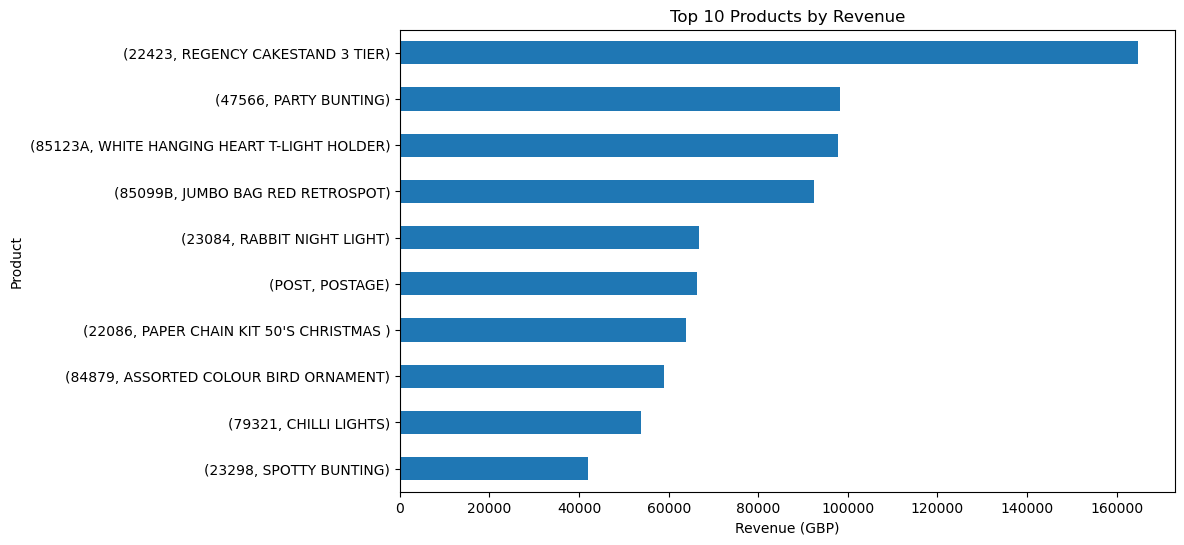

In [87]:
plt.figure(figsize=(10, 6))

top_10_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (GBP)')
plt.ylabel('Product')

plt.show()

### Business Insight

The top 10 products contribute a substantial share of the overall revenue, with a small number of products generating significantly more revenue than the rest. This indicates that revenue is concentrated among a limited group of high-performing products. These products could be prioritized for inventory management, promotion, and availability planning.

## 15. Repeat vs One-Time Customers

### Business Question
How many customers are repeat customers compared with customers who placed only one order?

### Approach
Count the number of unique orders placed by each customer. Customers with exactly one order will be classified as one-time customers, while customers with more than one order will be classified as repeat customers.

In [88]:
customer_orders = customer_df.groupby('CustomerID')['InvoiceNo'].nunique()

In [89]:
one_time_customers = customer_orders[customer_orders==1].count()
repeat_customers = customer_orders[customer_orders>1].count()
print("One-time customers:",one_time_customers)
print("Repeat customers:",repeat_customers)

One-time customers: 1317
Repeat customers: 3045


In [90]:
total_customers = one_time_customers + repeat_customers
one_time_pct = (one_time_customers/total_customers) * 100
repeat_pct = (repeat_customers/total_customers)*100
print("One-time customers:",one_time_pct)
print("Repeat customers:",repeat_pct)

One-time customers: 30.192572214580466
Repeat customers: 69.80742778541953


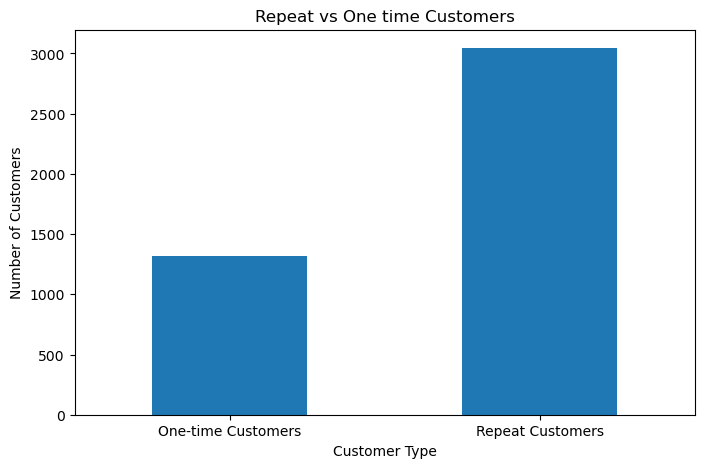

In [93]:
customer_type = pd.Series({
    'One-time Customers':one_time_customers,'Repeat Customers':repeat_customers
})
plt.figure(figsize=(8,5))
customer_type.plot(kind = 'bar')
plt.title('Repeat vs One time Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation = 0)
plt.show()

### Business Insight

Approximately 69.81% of customers are repeat customers, while 30.19% are one-time customers. The higher proportion of repeat customers indicates that a large part of the customer base returns to make additional purchases. This suggests relatively strong customer retention, although further analysis is needed to understand how frequently repeat customers purchase and how much revenue they contribute.

## 16. Customer Purchase Frequency

### Business Question
How frequently do customers place orders?

### Approach
Calculate the number of unique orders placed by each customer and analyze the distribution of purchase frequency. This will help identify how frequently customers return and whether a small group of highly active customers contributes significantly to the customer base.

In [94]:
customer_orders.value_counts().sort_index()

InvoiceNo
1      1317
2       817
3       491
4       378
5       283
       ... 
118       2
126       1
169       1
218       1
243       1
Name: count, Length: 63, dtype: int64

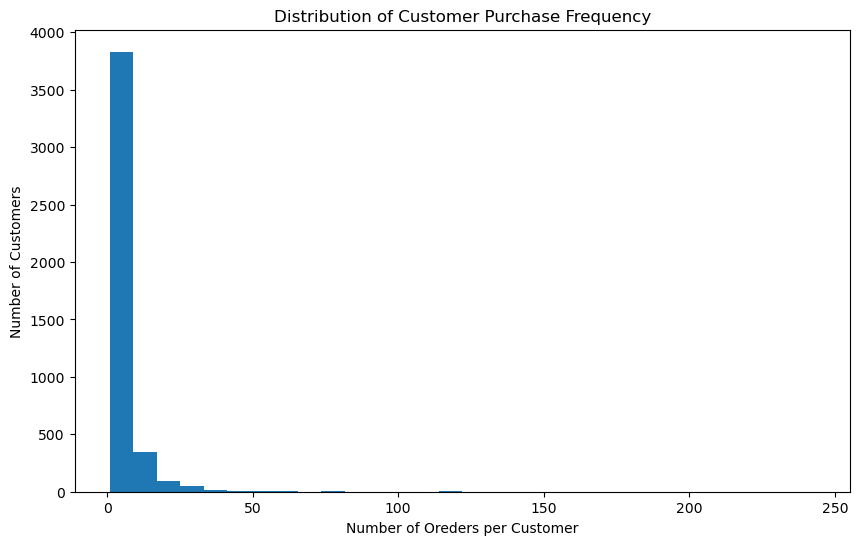

In [95]:
plt.figure(figsize=(10,6))
plt.hist(customer_orders,bins = 30)
plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Oreders per Customer')
plt.ylabel('Number of Customers')
plt.show()

### Business Insight

Customer purchase frequency is strongly right-skewed. Most customers place a relatively small number of orders, while only a small group of highly active customers place a very large number of orders. The maximum observed purchase frequency is 243 orders by a single customer. This suggests that customer engagement is concentrated among a small group of high-frequency buyers, who may be particularly valuable for retention and loyalty strategies.

##17- Top 10 Customers by Total Revenue

### Business Question
Which 10 customers have generated the highest total revenue?

### Approach
- Group the data by `CustomerID`.
- Calculate the total `Revenue` generated by each customer.
- Sort customers in descending order of revenue.
- Select the top 10 customers.

In [96]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

customer_revenue.head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

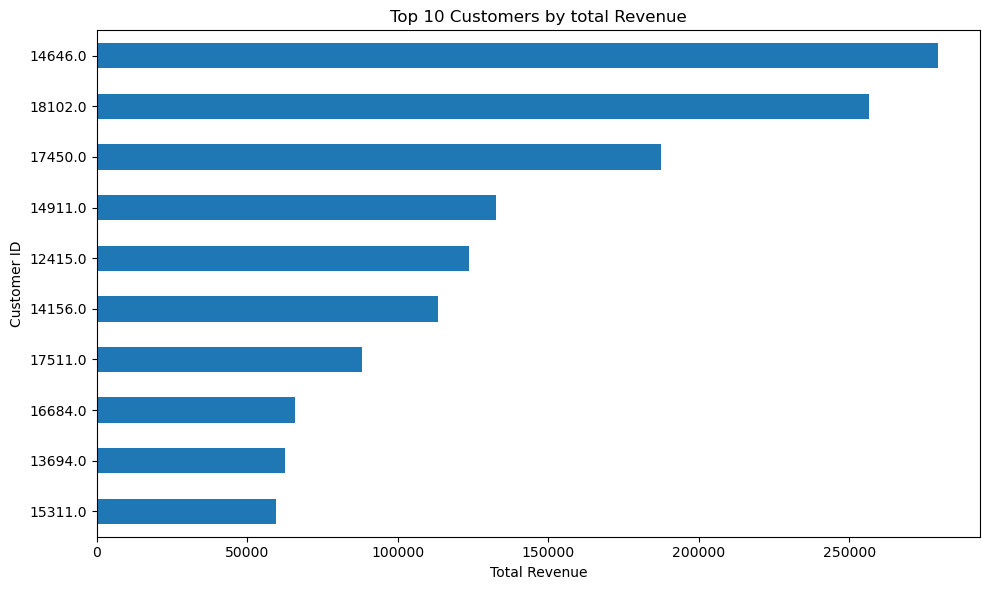

In [97]:
top_10_customers = customer_revenue.head(10)
plt.figure(figsize=(10,6))
top_10_customers.sort_values().plot(kind='barh')
plt.title('Top 10 Customers by total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

### Business Insight

The analysis shows that a small group of customers contributes significantly to total revenue. Customer 14646 is the highest-value customer, generating approximately 279K in revenue, followed by Customer 18102 with approximately 256K.

The noticeable gap between the top customers and the remaining customers suggests that high-value customers are particularly important to the business. These customers could be prioritized for retention strategies, personalized offers, and targeted marketing campaigns.

##18- Purchase Frequency vs. Total Revenue

### Business Question
Do customers who purchase more frequently also generate higher total revenue?

### Approach
- Calculate the number of unique invoices for each customer as their purchase frequency.
- Calculate the total revenue generated by each customer.
- Combine both metrics using `CustomerID`.
- Visualize the relationship between purchase frequency and total revenue using a scatter plot.
- Analyze whether higher purchase frequency is associated with higher revenue and identify any unusual customers.

In [2]:
%whos

Interactive namespace is empty.


In [3]:
import pandas as pd

In [4]:
df = pd.read_excel("C:\E-Commerce-DataAnalysis\data\Online_Retail.xlsx")

In [5]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [6]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [7]:
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()
customer_analysis = pd.DataFrame({
    'PurchaseFrequency': purchase_frequency,
    'TotalRevenue': customer_revenue
})

customer_analysis.head()

,PurchaseFrequency,TotalRevenue
CustomerID,,
12346.0,2,0.00
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40


In [9]:
import matplotlib.pyplot as plt

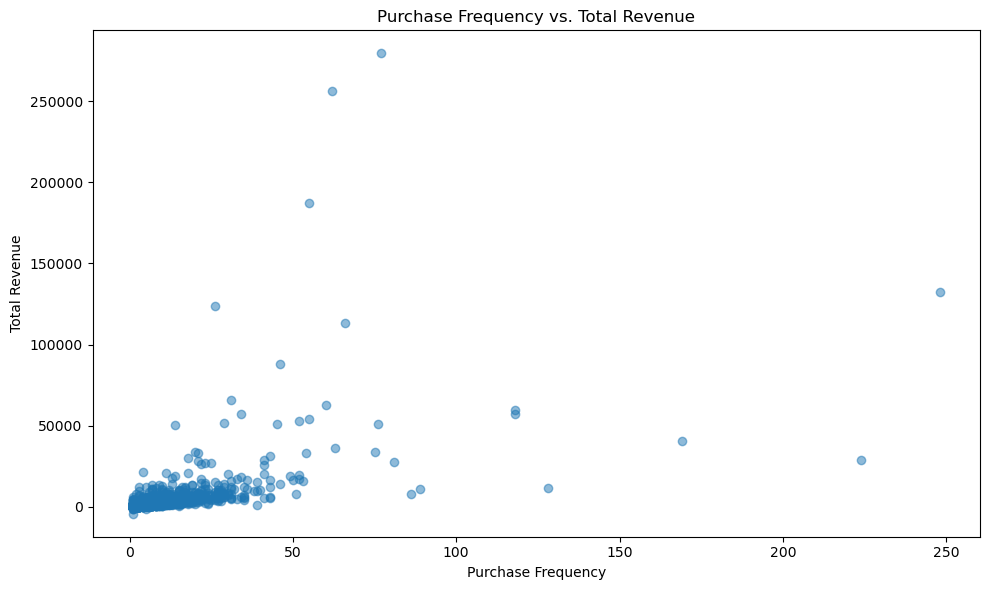

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_analysis['PurchaseFrequency'],
    customer_analysis['TotalRevenue'],
    alpha=0.5
)

plt.title('Purchase Frequency vs. Total Revenue')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Business Insight

The scatter plot shows a generally positive relationship between purchase frequency and total revenue. Customers with a higher number of purchases tend to generate more revenue, although the relationship is not perfectly linear.

Most customers are concentrated at lower purchase frequencies and lower revenue levels, while a small number of customers generate exceptionally high revenue. This indicates that customer value depends not only on how frequently customers purchase but also on the value of their individual purchases.

These high-value customers can be considered important targets for customer retention and personalized marketing strategies.

## Top 10 Products by Total Revenue

### Business Question
Which 10 products generate the highest total revenue?

### Approach
- Group the data by `StockCode`.
- Calculate the total revenue generated by each product.
- Sort the products in descending order of total revenue.
- Select the top 10 products.
- Visualize the results using a bar chart to compare their revenue contribution.

In [11]:
product_revenue = df.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False)

product_revenue.head(10)

StockCode
DOT       206245.48
22423     164762.19
47566      98302.98
85123A     97894.50
85099B     92356.03
23084      66756.59
POST       66230.64
22086      63791.94
84879      58959.73
79321      53768.06
Name: Revenue, dtype: float64

In [13]:
clean_df = df[df['UnitPrice'] > 0].copy()
non_product_codes = ['DOT','D','BANK CHARGES','CRUK','AMAZONFEE','M']

product_df = clean_df[~clean_df['StockCode'].isin(non_product_codes)]

product_df.groupby(['StockCode','Description'])['Revenue'].sum().sort_values(ascending=False)

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              164762.19
47566      PARTY BUNTING                          98302.98
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97715.99
85099B     JUMBO BAG RED RETROSPOT                92356.03
23084      RABBIT NIGHT LIGHT                     66756.59
                                                   ...    
21645      ASSORTED TUTTI FRUTTI ROUND BOX          -39.60
35400      WOODEN BOX ADVENT CALENDAR               -45.70
85063      CREAM SWEETHEART MAGAZINE RACK           -46.85
79323W     WHITE CHERRY LIGHTS                      -54.00
S          SAMPLES                                -3049.39
Name: Revenue, Length: 4171, dtype: float64

In [14]:
product_revenue = (
    product_df.groupby(['StockCode', 'Description'])['Revenue']
    .sum()
    .sort_values(ascending=False)
)

top_10_products = product_revenue.head(10)

top_10_products

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              164762.19
47566      PARTY BUNTING                          98302.98
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97715.99
85099B     JUMBO BAG RED RETROSPOT                92356.03
23084      RABBIT NIGHT LIGHT                     66756.59
POST       POSTAGE                                66230.64
22086      PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
84879      ASSORTED COLOUR BIRD ORNAMENT          58959.73
79321      CHILLI LIGHTS                          53768.06
23298      SPOTTY BUNTING                         42065.32
Name: Revenue, dtype: float64

In [15]:
product_df = product_df[product_df['StockCode'] != 'POST']

product_revenue = (
    product_df.groupby(['StockCode', 'Description'])['Revenue']
    .sum()
    .sort_values(ascending=False)
)

top_10_products = product_revenue.head(10)

top_10_products

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              164762.19
47566      PARTY BUNTING                          98302.98
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97715.99
85099B     JUMBO BAG RED RETROSPOT                92356.03
23084      RABBIT NIGHT LIGHT                     66756.59
22086      PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
84879      ASSORTED COLOUR BIRD ORNAMENT          58959.73
79321      CHILLI LIGHTS                          53768.06
23298      SPOTTY BUNTING                         42065.32
22386      JUMBO BAG PINK POLKADOT                41619.66
Name: Revenue, dtype: float64

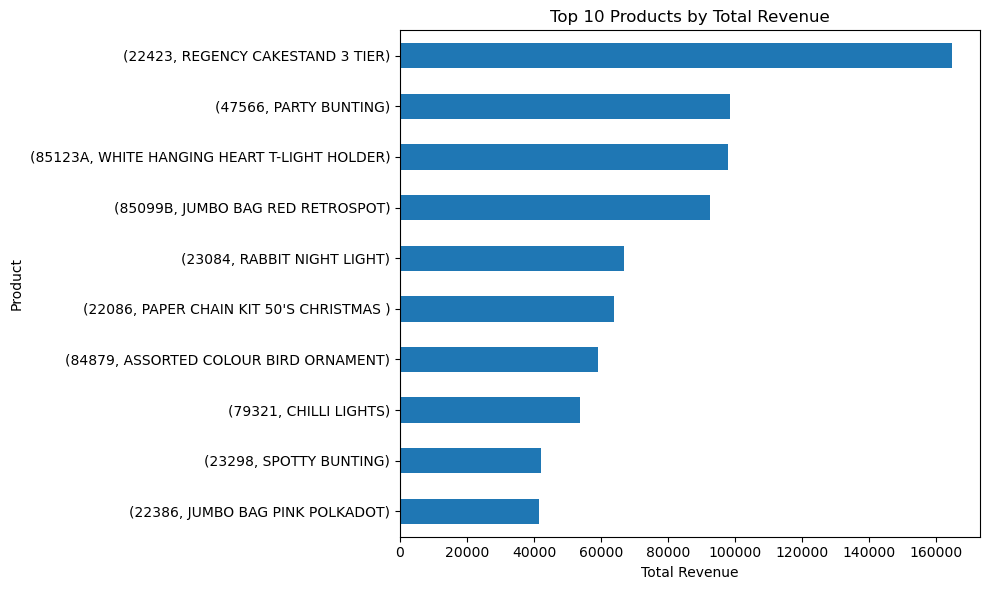

In [16]:
top_10_products.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

### Business Insight

The analysis shows that the **REGENCY CAKESTAND 3 TIER** is the highest revenue-generating product, with total revenue of approximately **164.8K**, significantly ahead of the other products.

The top-performing products are mainly decorative, gift, and household items, suggesting strong customer demand for these product categories. The noticeable gap between the top product and the lower-ranked products also indicates that revenue is concentrated among a smaller group of best-selling products.

These high-revenue products should be prioritized for inventory planning, promotional campaigns, and cross-selling opportunities to maximize future sales.

## Final Business Recommendations

Based on the analysis, the following recommendations can be made:

- **Focus on high-value customers:** A small group of customers contributes significantly to revenue, so targeted retention strategies and personalized offers can help maintain their loyalty.
- **Promote high-performing products:** Products generating the highest revenue should receive priority in inventory planning and promotional campaigns.
- **Encourage repeat purchases:** Since purchase frequency is generally associated with higher revenue, loyalty programs and personalized recommendations could help increase repeat purchases.
- **Plan inventory around demand:** Historical sales patterns and monthly revenue trends can be used to improve inventory planning and reduce the risk of stock shortages or excess inventory.
- **Monitor cancellations:** Tracking cancelled orders can help identify potential issues with products, pricing, inventory, or customer experience.

## Conclusion

This project analyzed an online retail dataset to understand sales performance, customer behavior, product performance, and revenue patterns. The analysis combined data cleaning, exploratory data analysis, customer and product analysis, and multiple visualizations to generate actionable business insights.